In [16]:
import oqupy
import oqupy.operators as op
import numpy as np
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
from oqupy.tti_tempo import TTITempoCounting
import matplotlib.pyplot as plt


from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize,Bounds

pt_parameters = {'epsrel':10**(-7),
                 'alpha':0.1,
                 'omega_cutoff':1,                 
                 'temp':0.131,
                 'dt':0.25}

omega_cutoff = pt_parameters['omega_cutoff']
alpha = pt_parameters['alpha']
temperature = pt_parameters['temp']
epsrel = pt_parameters['epsrel']
# dt = 1./omega_cutoff/np.sqrt(3)
dt=pt_parameters['dt']

tcut=27

Rho_0=oqupy.operators.spin_dm('x+')

# spectral density (without cutoff)
def j(w):
    return 2*alpha*w


In [17]:
correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=int(tcut/dt)+1)

In [18]:
u=0.01
correlationscf=oqupy.bath_correlations.CustomCountingSD(j_function=j,cutoff=omega_cutoff,u=u,
                                                 cutoff_type='exponential',temperature=temperature)

bathcf = oqupy.Bath(op.sigma("z")/2.0, correlationscf)

In [19]:
# converged parameters for different protocol times 
protocol_times=[10,50,70,100,200]

pt_var=TTITempo(bath,start_time=0.0,parameters=parameters)
process_tensor_var = pt_var.get_process_tensor()

pt_varcf=TTITempoCounting(bathcf,start_time=0.0,parameters=parameters)
process_tensor_varcf = pt_varcf.get_process_tensor()


building influence functional:  11%|█         | 12/109 [00:00<00:00, 117.67it/s]

building influence functional: 100%|██████████| 109/109 [00:44<00:00,  2.43it/s]


rank  378


/Users/eoinoneill/Desktop/PhD/ITT-tempo/OQuPy/oqupy/bath_correlations.py:1165: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  im_int += integrate.quad(im_integrand,
building influence functional:  15%|█▍        | 16/109 [00:00<00:00, 147.37it/s]

building influence functional: 100%|██████████| 109/109 [00:41<00:00,  2.60it/s]


rank  386


In [20]:
# serialization of process tensor (optional)
import dill

# processtensor_simplemodel
file_name1='processtensor_simplemodel'
with open(file_name1,'wb') as f:
    dill.dump(process_tensor_var,f)

# processtensor_simplemodel
file_name2='processtensorCF_simplemodel'
with open(file_name2,'wb') as f:
    dill.dump(process_tensor_varcf,f)


--> Compute dynamics:
100.0%    4 of    4 [########################################] 00:00:00
Elapsed time: 0.4s
--> Compute dynamics:
100.0%    4 of    4 [########################################] 00:00:00
Elapsed time: 0.3s


/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_5921/1975762112.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


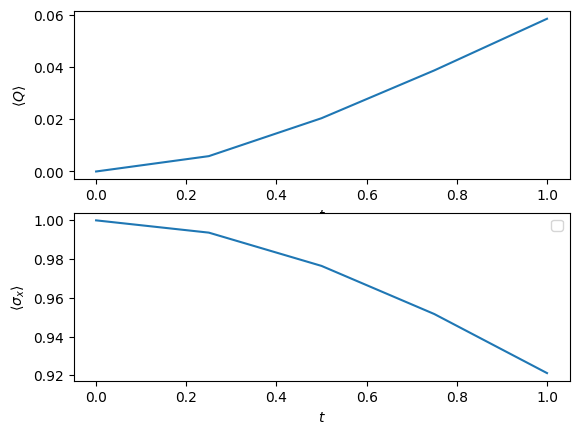

In [7]:

for t_prot in [1]:

   fig,axs=plt.subplots(2)

   num_steps=int(t_prot/dt)

   def hamiltonian_t(t):
      return pt_parameters['omega_cutoff']*op.sigma('x')*t/2 *(1/t_prot)

   system = oqupy.TimeDependentSystem(hamiltonian_t)

   # compute dynamics

   dynamics=oqupy.compute_dynamics(
   process_tensor=process_tensor_var,        
   system=system,
   initial_state=Rho_0,
   start_time=0,
   num_steps=num_steps)
   t, s_x = dynamics.expectations(op.sigma('x'), real=True)

   # compute heats

   dynamicscf = oqupy.compute_dynamics(
   process_tensor=process_tensor_varcf,        
   system=system,
   initial_state=Rho_0,
   start_time=0,
   num_steps=num_steps)

   heats=dynamicscf.states.trace(axis1=1,axis2=2).imag/u

   axs[0].plot(t,heats,label=t_prot)
   axs[0].set_xlabel(r'$t$')
   axs[0].set_ylabel(r'$\langle Q \rangle$')
   axs[1].plot(t,s_x)
   axs[1].set_xlabel(r'$t$')
   axs[1].set_ylabel(r'$\langle \sigma_x \rangle$')
   plt.legend()
   plt.show()


In [8]:
def discrete_hamiltonian(hx):
    return hx*op.sigma('x')/2
system = oqupy.ParameterizedSystem(discrete_hamiltonian)

target_derivative = -1j*np.identity(2)/u

In [9]:
# Cost Function
num_params=1

def heatandgrad(paras,process_tensor,num_steps):
    """""
    Take a numpy array [hx0, hz0, hx1, hz1, ...] over full timesteps and
    return the fidelity and gradient of the fidelity to the global target_derivative
    """

    # Reshape flat parameter list to form accepted by state_gradient: [[hx0,hz0],[hx1,hz1,]...]
    reshapedparas = [i for i in (paras.reshape((-1,num_params))).tolist() for j in range(2)]
    #parameter_list=np.array([itemopt_steps=[9] for pair in zip(paras[:num_steps],paras[num_steps:2*num_steps]) for item in pair])
    #reshapedparas = [i for i in (parameter_list.reshape((-1,num_params))).tolist() for j in range(2)]
    reshapedparas = np.array(reshapedparas)

    gradient_dict = oqupy.state_gradient(
        system=system,
        initial_state=Rho_0,
        target_derivative=target_derivative,
        process_tensors=[process_tensor],
        parameters=reshapedparas,
        num_steps=num_steps,
        progress_type='silent')
    
    fs=gradient_dict['final_state']
    gps=gradient_dict['gradient']

    heat=np.trace(fs).imag/u

    # Adding adjacent elements
    for i in range(0,gps.shape[0],2): 
        gps[i,:]=gps[i,:]+gps[i+1,:]
        
    gps=gps[0::2]

    x=[]
    for i in range(0,gps.shape[1]): 
        x.append(gps[:,i])
    
    gps=np.array(x)

    # Return the minus the gradient as infidelity is being minimized 
    return heat,(1.0*gps.reshape((-1)).real).tolist()

In [17]:
import time

opt_dict={protocol_times[0]:[],
                 protocol_times[1]:[], 
                 protocol_times[2]:[],
                 protocol_times[3]:[],
                 protocol_times[4]:[]}

min_heats=[]
opt_runtimes=[
]
#[10,20,50,70,100]
for t_prot in [10]:
    num_steps=int(t_prot/process_tensor_varcf.dt)
    hx=np.zeros(num_steps)
    parameter_list=[item for pair in zip(hx) for item in pair]
    start = time.time()
    
    optimization_result = minimize(
                            fun=heatandgrad,
                            x0=parameter_list,
                            args=(process_tensor_varcf,num_steps),
                            method='l-bfgs-b',
                            jac=True,
                            options = {'disp':True, 'gtol': 7e-04}
    )
    end = time.time()
    opt_runtimes.append(end-start)

    opt_dict[t_prot]=optimization_result

    min_heats.append(optimization_result.fun)

    print("The minimal heat was found to be : ",optimization_result.fun)

    print("The Jacobian was found to be : ",optimization_result.jac)

 60.0%  168 of  280 [########################----------------] 00:00:19RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           40     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  9.89721D-02    |proj g|=  1.24771D-02


 This problem is unconstrained.


 60.0%  168 of  280 [########################----------------] 00:00:23
At iterate    1    f=  6.22997D-02    |proj g|=  9.24117D-03
 60.0%  168 of  280 [########################----------------] 00:00:26
At iterate    2    f=  3.20125D-02    |proj g|=  5.09040D-03
 60.0%  168 of  280 [########################----------------] 00:00:29
At iterate    3    f=  1.97854D-02    |proj g|=  3.12376D-03
 60.0%  168 of  280 [########################----------------] 00:00:34
At iterate    4    f=  1.33103D-02    |proj g|=  1.58370D-03
 60.0%  168 of  280 [########################----------------] 00:00:38
At iterate    5    f=  1.03523D-02    |proj g|=  1.42513D-03
 60.0%  168 of  280 [########################----------------] 00:00:41
At iterate    6    f=  8.48377D-03    |proj g|=  9.66183D-04
 60.0%  168 of  280 [########################----------------] 00:00:45
At iterate    7    f=  6.51115D-03    |proj g|=  8.94755D-04
 60.0%  168 of  280 [########################----------------] 00:00:

 60.0%  168 of  280 [########################----------------] 3 days, 8:51:519

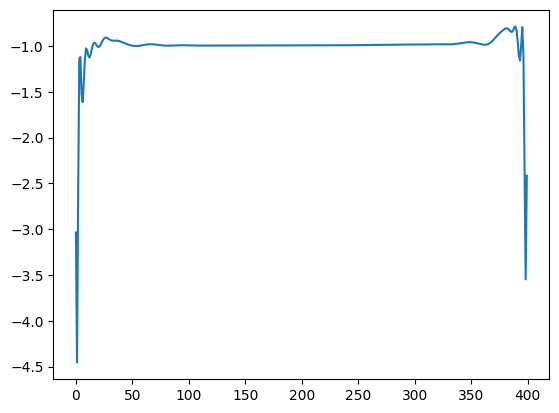

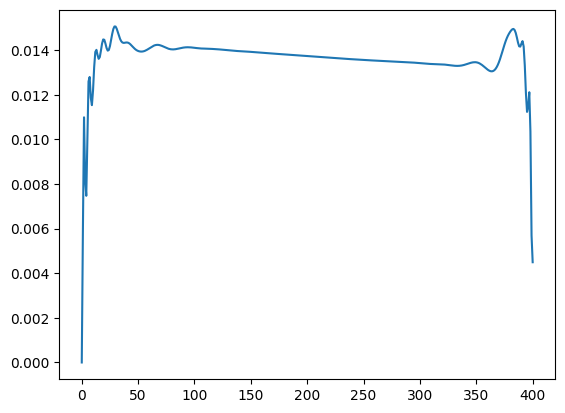

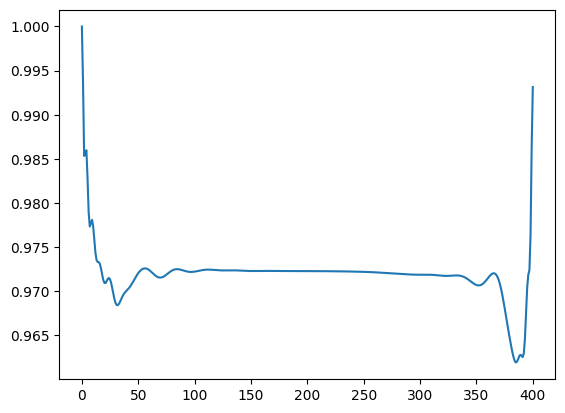

In [33]:
with open('results/constant_control/100ps/optimization_simplemodel_100ps', 'rb') as f:
    opt_dict100 = dill.load(f)

plt.plot(opt_dict100['result'].x)
plt.show()
plt.plot(opt_dict100['log'][-1]['full heats'])
plt.show()

dyn=opt_dict100['fidelitygrad']['dynamics']
t,sx=dyn.expectations(op.sigma('x'), real=True)
plt.plot(sx)
plt.show()

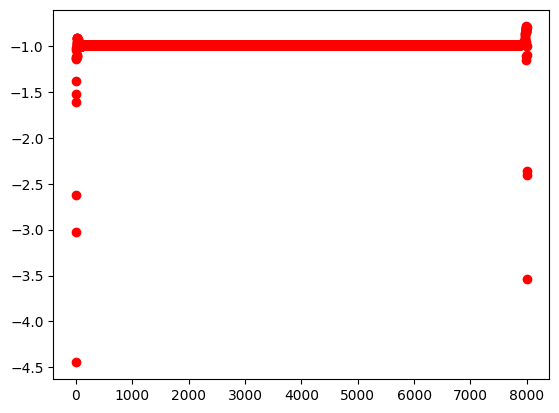

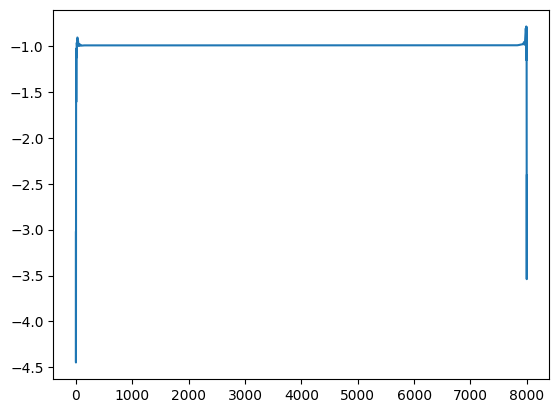

-0.023956850423403064


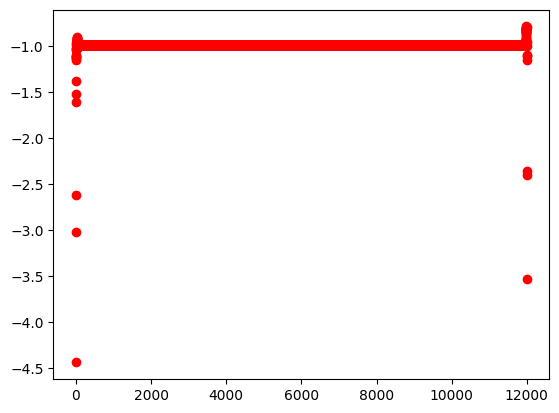

-0.03893293793587032


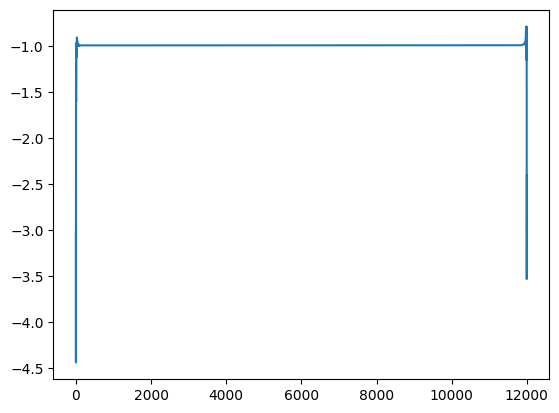

In [28]:
with open('optimization_simplemodel_2000ps', 'rb') as f:

    opt_result2000 = dill.load(f)
plt.plot(opt_result2000.x,'ro')
plt.show()
plt.plot(opt_result2000.x)
plt.show()
print(opt_result2000.fun)

with open('optimization_simplemodel_3000ps', 'rb') as f:

    opt_result3000 = dill.load(f)
plt.plot(opt_result3000.x,'ro')
plt.show()
plt.plot(opt_result3000.x)

print(opt_result3000.fun)

In [10]:
with open('optimization_simplemodel_1000ps', 'rb') as f:

    opt_result1000 = dill.load(f)

[-3.03361394 -4.45102981 -2.62000258 ... -2.36254326 -3.54357844
 -2.4133947 ]


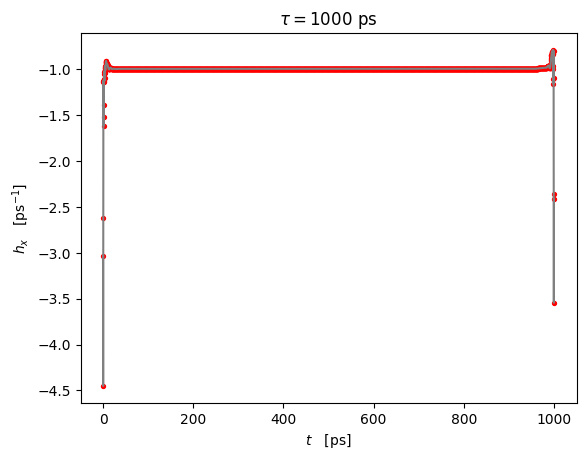

In [11]:
cs=['red','blue','pink','orange','green']
controlfigs_dict={protocol_times[0]:[],
                 protocol_times[1]:[], 
                 protocol_times[2]:[],
                 protocol_times[3]:[],
                 protocol_times[4]:[]}

#[10,20,50,70,100]

for i,t_prot in enumerate([1000]):
    opt_res=opt_result1000

    plt.title(r'$\tau={0}$ ps'.format(t_prot))
    plt.scatter(np.linspace(0,t_prot,len(opt_res.x)),opt_res.x,s=8,c=cs[i])
    plt.plot(np.linspace(0,t_prot,len(opt_res.x)),opt_res.x,c='gray')
    plt.xlabel(r'$t \quad[\text{ps}]$')
    plt.ylabel(r'$h_x \quad[\text{ps}^{-1}]$')
    print(opt_res.x)
    plt.show()
    

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_5921/227180342.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


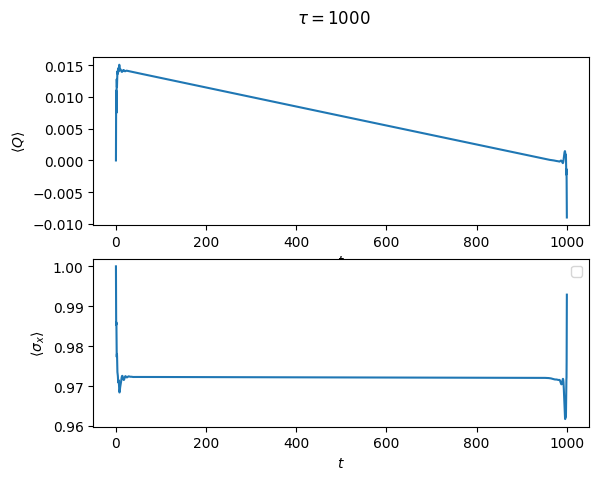

[[0.49988092-1.93708552e-12j 0.49645802-2.09751744e-12j]
 [0.49645802-2.14465926e-12j 0.49988092-1.91641085e-12j]]
(1.0000327335906065-8.98197916561574e-05j)


In [13]:
opt_grad_dict={protocol_times[0]:[],
                 protocol_times[1]:[], 
                 protocol_times[2]:[],
                 protocol_times[3]:[],
                 protocol_times[4]:[]}

for t_prot in [1000]:
    fig,axs=plt.subplots(2)
    fig.suptitle(r'$\tau={0}$'.format(t_prot))

    num_steps=int(t_prot/process_tensor_varcf.dt)
    opt_res=opt_result1000
    opt_parameters = reshapedparas = [i for i in (opt_res.x.reshape((-1,num_params))).tolist() for j in range(2)]
    opt_parameters=np.array(opt_parameters)

    grad_res_opt = oqupy.state_gradient(
        system=system,
        initial_state=Rho_0,
        target_derivative=target_derivative,
        process_tensors=[process_tensor_var],
        num_steps=num_steps,
        parameters=opt_parameters,
        progress_type='silent')

    dynamics=grad_res_opt['dynamics']
    t, s_x = dynamics.expectations(op.sigma('x'), real=True)

    grad_res_opt_cf = oqupy.state_gradient(
        system=system,
        initial_state=Rho_0,
        target_derivative=target_derivative,
        process_tensors=[process_tensor_varcf],
        num_steps=num_steps,
        parameters=opt_parameters,
        progress_type='silent')

    dynamicscf=grad_res_opt_cf['dynamics']
    heats=dynamicscf.states.trace(axis1=1,axis2=2).imag/u

    opt_grad_dict[t_prot]=grad_res_opt_cf

    axs[0].plot(t,heats,label=t_prot)
    axs[0].set_xlabel(r'$t$')
    axs[0].set_ylabel(r'$\langle Q \rangle$')
    axs[1].plot(t,s_x)
    axs[1].set_xlabel(r'$t$')
    axs[1].set_ylabel(r'$\langle \sigma_x \rangle$')
    plt.legend()
    plt.show()
    print(dynamics.states[-1])

print(np.trace(dynamicscf.states[-1]))
# Landauer erasure in the strong coupling regime inheritly requires a Non-Markovian control in order 

In [15]:
opt_result1000.fun

-0.008981979177584693

 30.5%  122 of  400 [############----------------------------] 6 days, 2:11:50

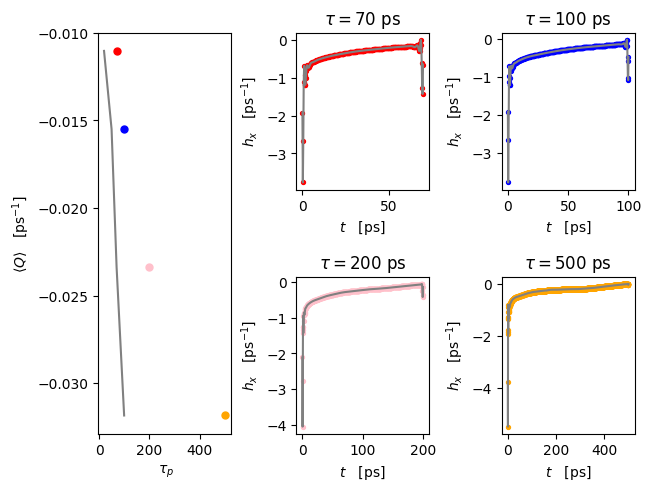

 30.5%  122 of  400 [############----------------------------] 6 days, 2:31:03

In [73]:
import matplotlib.gridspec as gridspec


cs=['red','blue','pink','orange','green']
final_heats=[]

fig = plt.figure(constrained_layout=True)
gs = gridspec.GridSpec(2, 3, figure=fig)

# Large plot on the left
ax1 = fig.add_subplot(gs[:, 0])

# 2x2 grid on the right
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[1, 2])

graphpositions={700:ax2,
                900:ax3,
                1000:ax4,
                1200:ax5}

u=0.01
for i,t_prot in enumerate([700,900,1000,1200]):
    dynamicscf=opt_grad_dict[t_prot]['dynamics']
    heats=dynamicscf.states.trace(axis1=1,axis2=2).imag/u
    final_heats.append(heats[-1])
    ax1.scatter(t_prot,heats[-1],s=25,c=cs[i])
    axs=graphpositions[t_prot]
    opt_res=opt_dict[t_prot]
    axs.set_title(r'$\tau={0}$ ps'.format(t_prot))
    axs.scatter(np.linspace(0,t_prot,len(opt_res.x)),opt_res.x,s=8,c=cs[i])
    axs.plot(np.linspace(0,t_prot,len(opt_res.x)),opt_res.x,c='gray')
    axs.set_xlabel(r'$t \quad[\text{ps}]$')
    axs.set_ylabel(r'$h_x \quad[\text{ps}^{-1}]$')


ax1.plot([20,50,70,100],final_heats,c='gray')
ax1.set_xlabel(r' $\tau_p$ ')
ax1.set_ylabel(r'$\langle Q \rangle \quad[\text{ps}^{-1}]$')
plt.show()

# course graining
# 

In [47]:
from scipy.optimize import curve_fit

def control_analytic(t, T, alpha, omega, sigma):
    """
    Analytic bang-bang-inspired control function.

    Parameters:
    - t     : float or ndarray, time(s) at which to evaluate the control
    - T     : float, total duration of the protocol
    - alpha : float, slope of the linear ramp in the middle
    - omega : float, frequency of oscillations at the edges
    - sigma : float, width of the envelope for oscillations (smaller = more localized)

    Returns:
    - u(t) : control value(s) at time t
    """
    t = np.asarray(t)
    A_t = np.exp(-((t - T/2) / sigma) ** 4)
    B_t = alpha * t
    return A_t * np.sin(omega * t) + B_t

t_prot=20
t=np.linspace(0,t_prot,len(opt_dict[t_prot].x))
popt,pcov=curve_fit(control_analytic,t,opt_dict[t_prot].x)

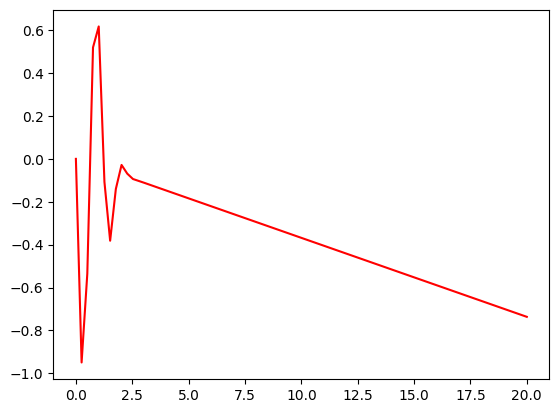

In [48]:
plt.plot(t ,control_analytic(t, *popt), 'r-')

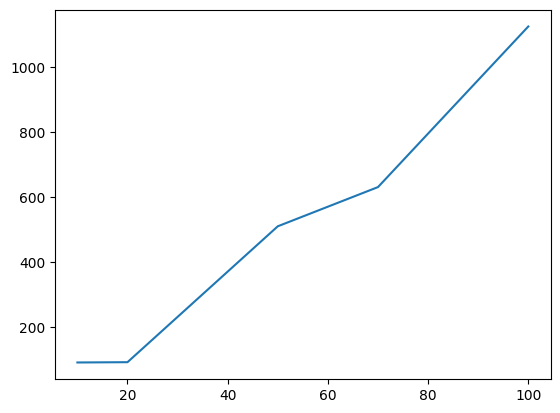

 30.5%  122 of  400 [############----------------------------] 5 days, 23:39:31

In [49]:
plt.plot([10,20,50,70,100],opt_runtimes)